# Healthcare Early-Warning AI using Synthetic EHR Data (Synthea)

This notebook builds an early-warning machine learning model using synthetic electronic health record (EHR) data generated by **Synthea**.

**Goal:** Predict the short-term risk that a patient will require a **hospital encounter** (e.g. inpatient / emergency visit) based on their past clinical history and demographics.

This type of model is similar in spirit to research done with real ICU/EHR datasets (e.g. MIMIC, eICU), but here we use synthetic data so that we can freely experiment without any privacy issues.


## **2. Project Plan**

*   List item
*   List item



We will follow these steps:

1. **Set up environment**  
   - Mount Google Drive  
   - Define data paths  
   - Import core Python libraries

2. **Load Synthea data (CSV)**  
   - `patients.csv`  
   - `encounters.csv`  
   - `conditions.csv`  
   - `observations.csv`

3. **Understand the data model**  
   - How tables relate to each other  
   - Basic exploratory analysis

4. **Define prediction problem**  
   - Early-warning label: *Will this patient have a hospital encounter in the next 30 days?*

5. **Build analysis dataset**  
   - Aggregate patient-level features from multiple tables  
   - Create the target label

6. **Train baseline models**  
   - Logistic Regression / Random Forest / Gradient Boosting  
   - Evaluate with ROC-AUC, Precision, Recall


In [2]:
# 1.1 Mount Google Drive to access data files
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 1.2 Set the path to the Synthea CSV folder and list available files
import os

DATA_DIR = "/content/drive/MyDrive/synthea"  # change if your folder name/path is different

# Show files in the directory to confirm the path is correct
os.listdir(DATA_DIR)

['encounters.csv',
 'providers.csv',
 'allergies.csv',
 'careplans.csv',
 'conditions.csv',
 'imaging_studies.csv',
 'immunizations.csv',
 'payers.csv',
 'supplies.csv',
 'medications.csv',
 'payer_transitions.csv',
 'devices.csv',
 'claims_transactions.csv',
 'observations.csv',
 'procedures.csv',
 'claims.csv',
 'organizations.csv',
 'patients.csv']

In [4]:
# 1.3 Import core Python libraries for analysis and modelling

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Make plots a bit prettier and larger
plt.style.use("default")
sns.set()

## **3. Load Synthea CSV Tables**

Synthea provides multiple linked tables that represent different aspects of a patient's medical history:

- **patients.csv** – one row per patient (demographics).
- **encounters.csv** – clinical visits/contacts with the healthcare system.
- **conditions.csv** – diagnoses assigned to patients.
- **observations.csv** – measurements such as vitals or lab-like values.

In this step we load these tables into Pandas DataFrames for exploration.


In [5]:
# 2.1 Load core Synthea tables

patients = pd.read_csv(f"{DATA_DIR}/patients.csv")
encounters = pd.read_csv(f"{DATA_DIR}/encounters.csv")
conditions = pd.read_csv(f"{DATA_DIR}/conditions.csv")
observations = pd.read_csv(f"{DATA_DIR}/observations.csv")

In [6]:
# 2.2 Inspect the first few rows of each table to understand the structure

print("Patients:")
display(patients.head())

print("\nEncounters:")
display(encounters.head())

print("\nConditions:")
display(conditions.head())

print("\nObservations:")
display(observations.head())

Patients:


,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,...,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,45dff467-def6-2132-a03a-5950e203b5c8,1977-11-05,NaN,999-99-5823,S99991279,X28392886X,Mr.,Kris249,Ezequiel972,Moore224,...,Hudson,Massachusetts,Middlesex County,25017.0,1749,42.412388,-71.523562,104982.28,10945.37,45797
1,41e3b05f-43dc-a488-c593-d14d479b9091,1962-05-13,NaN,999-58-7605,S99923886,X25494937X,Mr.,Boyce638,Howard613,Hansen121,...,Leominster,Massachusetts,Worcester County,25027.0,1420,42.517587,-71.773606,127438.38,85176.74,82489
2,0bdb38c0-fe9f-f2dd-f7e0-0ba7eddb4738,1962-06-03,NaN,999-32-8956,S99960713,X16309304X,Mr.,Jody426,Dallas143,McGlynn426,...,Wakefield,Massachusetts,Middlesex County,25009.0,1940,42.549621,-70.998783,466903.21,89646.91,45298
3,10ecc353-34e9-2ab7-dea9-b7ff6b838b20,2020-08-08,NaN,999-94-6606,NaN,NaN,NaN,Azalee124,Reena181,Ankunding277,...,Hatfield,Massachusetts,Hampshire County,25015.0,1038,42.372674,-72.641256,9687.19,5.33,64825
4,092055e1-eb28-57d2-d914-ab03727a4ebc,2007-06-18,NaN,999-62-7403,S99996282,NaN,Ms.,Michaela318,Ela754,Von197,...,Swampscott,Massachusetts,Essex County,25009.0,1907,42.510106,-70.869277,60036.06,8297.63,134174



Encounters:


,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,45dff467-def6-2132-8f92-39a4105bfc61,1987-01-27T05:21:42Z,1987-01-27T05:36:42Z,45dff467-def6-2132-a03a-5950e203b5c8,352f2e3b-0708-3eb4-9f7e-e73a685bf379,1978b98a-2521-37db-bde4-3ecf576b55f3,e03e23c9-4df1-3eb6-a62d-f70f02301496,ambulatory,185345009,Encounter for symptom (procedure),85.55,92.93,0.0,36971009.0,Sinusitis (disorder)
1,45dff467-def6-2132-3703-014f32323de2,1995-12-30T07:21:42Z,1995-12-30T08:12:09Z,45dff467-def6-2132-a03a-5950e203b5c8,981338c4-287c-3621-bc45-8b0b9f1b8922,8f4c2d28-11d6-3fda-a362-0eed0b3d6342,e03e23c9-4df1-3eb6-a62d-f70f02301496,wellness,162673000,General examination of patient (procedure),136.80,922.00,0.0,NaN,NaN
2,45dff467-def6-2132-b4aa-505b537b65ae,2003-01-11T07:21:42Z,2003-01-11T08:19:35Z,45dff467-def6-2132-a03a-5950e203b5c8,981338c4-287c-3621-bc45-8b0b9f1b8922,8f4c2d28-11d6-3fda-a362-0eed0b3d6342,e03e23c9-4df1-3eb6-a62d-f70f02301496,wellness,162673000,General examination of patient (procedure),136.80,919.90,0.0,NaN,NaN
3,45dff467-def6-2132-4c1b-fd91dc11097b,2006-01-14T07:21:42Z,2006-01-14T08:17:26Z,45dff467-def6-2132-a03a-5950e203b5c8,981338c4-287c-3621-bc45-8b0b9f1b8922,8f4c2d28-11d6-3fda-a362-0eed0b3d6342,e03e23c9-4df1-3eb6-a62d-f70f02301496,wellness,162673000,General examination of patient (procedure),136.80,1577.04,0.0,NaN,NaN
4,45dff467-def6-2132-dd74-9b491ab2b598,2010-08-21T07:21:42Z,2010-08-21T08:04:13Z,45dff467-def6-2132-a03a-5950e203b5c8,352f2e3b-0708-3eb4-9f7e-e73a685bf379,1978b98a-2521-37db-bde4-3ecf576b55f3,8fa6c185-e44e-3e34-8bd8-39be8694f4ce,outpatient,185349003,Encounter for check up (procedure),85.55,950.03,0.0,NaN,NaN



Conditions:


,START,STOP,PATIENT,ENCOUNTER,SYSTEM,CODE,DESCRIPTION
0,1987-01-27,NaN,45dff467-def6-2132-a03a-5950e203b5c8,45dff467-def6-2132-8f92-39a4105bfc61,http://snomed.info/sct,40055000,Chronic sinusitis (disorder)
1,1995-12-30,NaN,45dff467-def6-2132-a03a-5950e203b5c8,45dff467-def6-2132-3703-014f32323de2,http://snomed.info/sct,224299000,Received higher education (finding)
2,2003-01-11,NaN,45dff467-def6-2132-a03a-5950e203b5c8,45dff467-def6-2132-b4aa-505b537b65ae,http://snomed.info/sct,422650009,Social isolation (finding)
3,2003-01-11,NaN,45dff467-def6-2132-a03a-5950e203b5c8,45dff467-def6-2132-b4aa-505b537b65ae,http://snomed.info/sct,266948004,Has a criminal record (finding)
4,2006-01-14,NaN,45dff467-def6-2132-a03a-5950e203b5c8,45dff467-def6-2132-4c1b-fd91dc11097b,http://snomed.info/sct,714628002,Prediabetes (finding)



Observations:


,DATE,PATIENT,ENCOUNTER,CATEGORY,CODE,DESCRIPTION,VALUE,UNITS,TYPE
0,2017-11-11T07:21:42Z,45dff467-def6-2132-a03a-5950e203b5c8,45dff467-def6-2132-9e5c-0a836d754d92,laboratory,4548-4,Hemoglobin A1c/Hemoglobin.total in Blood,5.8,%,numeric
1,2017-11-11T07:21:42Z,45dff467-def6-2132-a03a-5950e203b5c8,45dff467-def6-2132-9e5c-0a836d754d92,vital-signs,8302-2,Body Height,186.4,cm,numeric
2,2017-11-11T07:21:42Z,45dff467-def6-2132-a03a-5950e203b5c8,45dff467-def6-2132-9e5c-0a836d754d92,vital-signs,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,3.0,{score},numeric
3,2017-11-11T07:21:42Z,45dff467-def6-2132-a03a-5950e203b5c8,45dff467-def6-2132-9e5c-0a836d754d92,vital-signs,29463-7,Body Weight,98.0,kg,numeric
4,2017-11-11T07:21:42Z,45dff467-def6-2132-a03a-5950e203b5c8,45dff467-def6-2132-9e5c-0a836d754d92,vital-signs,39156-5,Body mass index (BMI) [Ratio],28.2,kg/m2,numeric


## **4**. Data Model – How the Tables Link Together

Each table uses a patient identifier so that we can connect information across tables:

- `patients.Id` is the unique ID for each patient.
- `encounters.PATIENT` refers to `patients.Id`.
- `conditions.PATIENT` refers to `patients.Id`.
- `observations.PATIENT` refers to `patients.Id`.

So the relationships are:

- **Patients 1 ↔ N Encounters**
- **Patients 1 ↔ N Conditions**
- **Patients 1 ↔ N Observations**

This is similar to real electronic health records (EHR) systems.  
We will eventually build a **patient-level dataset** that aggregates information from all these tables.


## **5**. Data Quality & Missingness (EHR Perspective)

Unlike typical Kaggle/tabular datasets, missing values in health records are usually **informative** and should not be discarded without reflection.

For example:
- If a patient has **no observations (vitals/labs)**, it may indicate they were not admitted or not acutely ill.
- If a patient has **no chronic conditions**, they may be healthy.
- If a patient has **no inpatient encounters**, they may not have required acute care.

Before building features, we will:
1. Inspect null values
2. Examine missingness patterns across tables
3. Decide which missingness should become a feature rather than being dropped


In [7]:
# 4.1 Check missingness across main tables

def missing_summary(df):
    return pd.DataFrame({
        'missing_count': df.isna().sum(),
        'missing_pct': df.isna().mean() * 100
    }).sort_values('missing_pct', ascending=False)

print("Patients missingness:")
display(missing_summary(patients))

print("\nEncounters missingness:")
display(missing_summary(encounters))

print("\nConditions missingness:")
display(missing_summary(conditions))

print("\nObservations missingness:")
display(missing_summary(observations))

Patients missingness:


,missing_count,missing_pct
SUFFIX,115,100.000000
DEATHDATE,100,86.956522
MAIDEN,88,76.521739
MARITAL,39,33.913043
PASSPORT,24,20.869565
PREFIX,22,19.130435
MIDDLE,20,17.391304
DRIVERS,19,16.521739
FIPS,18,15.652174
BIRTHDATE,0,0.000000



Encounters missingness:


,missing_count,missing_pct
REASONCODE,2649,37.336152
REASONDESCRIPTION,2649,37.336152
Id,0,0.000000
PATIENT,0,0.000000
ORGANIZATION,0,0.000000
START,0,0.000000
STOP,0,0.000000
PAYER,0,0.000000
PROVIDER,0,0.000000
ENCOUNTERCLASS,0,0.000000



Conditions missingness:


,missing_count,missing_pct
STOP,1087,24.069973
START,0,0.000000
PATIENT,0,0.000000
ENCOUNTER,0,0.000000
SYSTEM,0,0.000000
CODE,0,0.000000
DESCRIPTION,0,0.000000



Observations missingness:


,missing_count,missing_pct
UNITS,26729,27.926196
CATEGORY,3225,3.369448
ENCOUNTER,3225,3.369448
DATE,0,0.000000
PATIENT,0,0.000000
CODE,0,0.000000
DESCRIPTION,0,0.000000
VALUE,0,0.000000
TYPE,0,0.000000


### Why We Do Not Simply Clean or Drop Missing Values

In typical machine learning datasets (e.g., Kaggle competitions), missing values are often treated as noise and removed or imputed. However, electronic health record (EHR) data has fundamentally different missingness characteristics:

- **Missingness is often informative**  
  The absence of certain measurements (e.g., vitals, labs) can indicate lower disease severity or lack of acute care.

- **Clinical concepts are time-dependent**  
  A patient may not have a `STOP` time for chronic conditions because the condition is ongoing.

- **Not all patients undergo the same assessments**  
  Lack of observations or encounters can be a clinically meaningful feature.

- **Data is heterogeneous and event-based**  
  Patients interact with the healthcare system based on need, not uniform schedules.

For these reasons, we do **not** drop rows with missing values at this stage. Instead, missingness will later be transformed into **features** (e.g., number of observations, presence/absence of inpatient encounters), which can provide predictive signal for early-warning tasks.

In the clinical machine learning literature, missing data is considered part of the underlying data-generating process rather than a preprocessing artifact. Prior work has shown that incorporating missingness as a feature can improve predictive performance in ICU and hospital readmission models (e.g., MIMIC, eICU, Deep EHR studies).



## **6**. Define Early-Warning Prediction Target (30-Day Horizon)

To frame this dataset as a supervised learning problem, we define a binary prediction target at the patient level.

**Prediction Question:**  
> Will the patient experience a hospital-type encounter (e.g. inpatient or emergency encounter) within the next 30 days?

This type of task is commonly studied in clinical machine learning for proactive risk detection, triage, and resource planning.

To compute this target, we will:

1. Identify "hospital encounters" from the `encounters.csv` table.
2. Sort encounters chronologically for each patient.
3. For each encounter, check whether another hospital encounter occurs within the next 30 days.
4. Assign a binary target (`1` = event occurs, `0` = no event).

In [8]:
# 5.1 Convert relevant date columns to datetime format

encounters['START'] = pd.to_datetime(encounters['START'])
encounters['STOP'] = pd.to_datetime(encounters['STOP'], errors='coerce')  # chronic events can have no STOP
conditions['START'] = pd.to_datetime(conditions['START'])
conditions['STOP'] = pd.to_datetime(conditions['STOP'], errors='coerce')
observations['DATE'] = pd.to_datetime(observations['DATE'])
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'])
patients['DEATHDATE'] = pd.to_datetime(patients['DEATHDATE'], errors='coerce')

In [9]:
# 5.2 Identify hospital-type encounters (positive signal candidates)

hospital_classes = ['inpatient', 'emergency', 'urgentcare']

encounters['hospital_flag'] = encounters['ENCOUNTERCLASS'].isin(hospital_classes).astype(int)

In [10]:
# 5.3 Sort encounters by time within each patient
encounters = encounters.sort_values(by=['PATIENT', 'START'])

In [11]:
# 5.4 Generate 30-day early-warning target

from datetime import timedelta

def compute_target(df, horizon=30):
    df = df.copy()
    df['target_30d'] = 0
    for idx in range(len(df)):
        if df.iloc[idx]['hospital_flag'] == 1:
            current_start = df.iloc[idx]['START']
            lookahead = current_start + timedelta(days=horizon)

            future = df[
                (df['START'] > current_start) &
                (df['START'] <= lookahead) &
                (df['hospital_flag'] == 1)
            ]

            if len(future) > 0:
                df.at[df.index[idx], 'target_30d'] = 1
    return df

encounters = encounters.groupby('PATIENT').apply(compute_target).reset_index(drop=True)

/tmp/ipykernel_1228/84879388.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  encounters = encounters.groupby('PATIENT').apply(compute_target).reset_index(drop=True)


In [12]:
# 5.5 Check class distribution
encounters['target_30d'].value_counts()

,count
target_30d,
0,6772
1,323


## **7**. Encounter-Level Prediction Framing

We frame this problem at the **encounter level**, meaning each clinical encounter serves as a reference point from which we predict whether the patient will require another hospital encounter within a short future horizon (30 days in our case).

This approach aligns with early-warning and deterioration prediction models frequently used in clinical machine learning research, particularly in ICU and hospital readmission studies.

Advantages of encounter-level framing:

- Treats patient history as a temporal sequence of events.
- Allows for multiple predictions per patient.
- Respects clinical workflows such as triage and discharge.
- Enables the use of temporal models (e.g., sequence models, LSTMs) if desired later.


### 7.1 Target Definition Finalization

From the previous step, we computed a binary target `target_30d` indicating whether a subsequent hospital encounter occurred within 30 days after a given encounter.

Since not all encounters are hospital encounters, we retain only encounters that could realistically precede a hospital event, and drop those where the patient has no future encounters recorded.


In [13]:
# 7.2 Filter encounters to meaningful rows

# Remove encounters without a START timestamp (should be none, but safe)
encounters = encounters[~encounters['START'].isna()]

# Optionally drop patients with only a single encounter (no temporal info)
encounters = encounters.groupby('PATIENT').filter(lambda x: len(x) > 1).reset_index(drop=True)

Patients with only 1 encounter can’t form a future event, so they don’t contribute to supervised training.

In [14]:
# 7.3 Examine class distribution
encounters['target_30d'].value_counts(normalize=True).to_frame('proportion') ## This tells us how often the next 30-day hospital event occurs.

,proportion
target_30d,
0,0.954469
1,0.045531


## **8**. Feature Engineering (Encounter-Level)

To train a supervised model, we need to transform raw EHR tables into structured features that summarize patient status at each encounter.

For encounter-level modeling, we extract:

1. **Demographics (from patients.csv)**
    - age at encounter time
    - sex
    - race/ethnicity

2. **Encounter History**
    - total number of past encounters
    - number of emergency encounters in last 30/60/90 days
    - number of inpatient encounters in last 30/60/90 days

3. **Condition Burden (from conditions.csv)**
    - number of chronic conditions
    - number of active conditions at encounter time
    - comorbidity-like indicators

4. **Observation History (from observations.csv)**
    - count of lab/vital measurements
    - whether labs were ordered (yes/no)
    - missingness as signal

These features are commonly used in real EHR research and allow for flexible modeling approaches from logistic regression to sequence deep learning.


In [15]:
# 7.1 Merge patient demographics into encounter table

# Clean patient ID column names for merge
patients.rename(columns={'Id':'PATIENT'}, inplace=True)

enc = encounters.merge(
    patients[['PATIENT','BIRTHDATE','DEATHDATE','GENDER','RACE','ETHNICITY']],
    on='PATIENT',
    how='left'
)


In [16]:
# Ensure both datetime fields are tz-naive before subtraction
enc['START'] = enc['START'].dt.tz_localize(None)
enc['BIRTHDATE'] = enc['BIRTHDATE'].dt.tz_localize(None)

# Compute age at encounter time
enc['age'] = (enc['START'] - enc['BIRTHDATE']).dt.days / 365.25

### Handling Timezone-Aware Timestamps

Synthea encounter timestamps may include timezone information, whereas patient birthdates typically do not. Python does not allow subtraction between timezone-aware and timezone-naive datetimes. To enable valid time arithmetic, we strip timezone information using `.dt.tz_localize(None)` which preserves date values while harmonizing formats.


In [17]:
enc[['PATIENT','START','ENCOUNTERCLASS','age','target_30d']].head()

,PATIENT,START,ENCOUNTERCLASS,age,target_30d
0,0050142f-2f30-0459-4614-3b9cbb082854,2010-04-30 11:30:41,ambulatory,1.015743,0
1,0050142f-2f30-0459-4614-3b9cbb082854,2015-04-10 11:30:41,wellness,5.960301,0
2,0050142f-2f30-0459-4614-3b9cbb082854,2016-04-15 11:30:41,wellness,6.976044,0
3,0050142f-2f30-0459-4614-3b9cbb082854,2017-04-21 11:30:41,wellness,7.991786,0
4,0050142f-2f30-0459-4614-3b9cbb082854,2018-04-27 11:30:41,wellness,9.007529,0


### Condition-Based Features

Chronic and active conditions are strong predictors of healthcare utilization and acute deterioration risk.

From `conditions.csv` we extract:

- **Number of active conditions at encounter**
- **Total number of historical conditions**
- **Presence of chronic diseases**

This serves as a proxy for disease burden and comorbidity, which are commonly used in clinical machine learning studies.


In [18]:
# Ensure conditions have proper datetime format
conditions['START'] = pd.to_datetime(conditions['START'])
conditions['STOP'] = pd.to_datetime(conditions['STOP'], errors='coerce')

A condition is active at an encounter if:

condition.START <= encounter.START <= condition.STOP (or STOP is missing)


Missing STOP means condition is chronic/ongoing → common in clinical data.

In [19]:
# Function to count active conditions at encounter time
def count_active_conditions(enc_row):
    pid = enc_row['PATIENT']
    t = enc_row['START']

    conds = conditions[conditions['PATIENT'] == pid]

    active = conds[
        (conds['START'] <= t) &
        ((conds['STOP'].isna()) | (conds['STOP'] >= t))
    ]

    return len(active)

enc['active_conditions'] = enc.apply(count_active_conditions, axis=1)

In [20]:
enc[['PATIENT','START','active_conditions','target_30d']].head()

,PATIENT,START,active_conditions,target_30d
0,0050142f-2f30-0459-4614-3b9cbb082854,2010-04-30 11:30:41,1,0
1,0050142f-2f30-0459-4614-3b9cbb082854,2015-04-10 11:30:41,2,0
2,0050142f-2f30-0459-4614-3b9cbb082854,2016-04-15 11:30:41,1,0
3,0050142f-2f30-0459-4614-3b9cbb082854,2017-04-21 11:30:41,2,0
4,0050142f-2f30-0459-4614-3b9cbb082854,2018-04-27 11:30:41,1,0


We treat `active_conditions` as a proxy for chronic disease burden. Higher values should correlate with higher future utilization risk.


### Encounter History Features (Temporal)

Healthcare utilization patterns are predictive of future encounters.

We compute:

- Number of past encounters
- Number of emergency encounters (past 30/60/90 days)
- Number of inpatient encounters (past 30/60/90 days)
- Time since last encounter

These features capture temporal care patterns relevant in deterioration prediction.


In [21]:
from datetime import timedelta

windows = [30, 60, 90]

for w in windows:
    col = f'past_encounters_{w}d'
    vals = []

    for i, row in enc.iterrows():
        pid = row['PATIENT']
        t = row['START']
        t_low = t - timedelta(days=w)

        subset = enc[(enc['PATIENT'] == pid) & (enc['START'] < t) & (enc['START'] >= t_low)]
        vals.append(len(subset))

    enc[col] = vals



In [22]:
enc[['PATIENT','START','past_encounters_30d','past_encounters_60d','past_encounters_90d']].head()

,PATIENT,START,past_encounters_30d,past_encounters_60d,past_encounters_90d
0,0050142f-2f30-0459-4614-3b9cbb082854,2010-04-30 11:30:41,0,0,0
1,0050142f-2f30-0459-4614-3b9cbb082854,2015-04-10 11:30:41,0,0,0
2,0050142f-2f30-0459-4614-3b9cbb082854,2016-04-15 11:30:41,0,0,0
3,0050142f-2f30-0459-4614-3b9cbb082854,2017-04-21 11:30:41,0,0,0
4,0050142f-2f30-0459-4614-3b9cbb082854,2018-04-27 11:30:41,0,0,0


##  Observation-Based Features (Labs/Vitals Activity)

Clinical measurements such as labs and vital signs often serve as strong indicators of patient health status.
In addition, the frequency of measurements carries information: high monitoring density can indicate clinical concern or deterioration.

From `observations.csv` we compute:

- number of observations before each encounter
- number of observations in recent temporal windows (30, 60, 90 days)
- whether observations exist at all (missingness → signal)

These features are suitable for classical ML baselines.


In [23]:
# Ensure datetime types (already done previously but safe to repeat)
observations['DATE'] = pd.to_datetime(observations['DATE'], errors='coerce')

# Harmonize timezone (very important for datetime comparisons)
observations['DATE'] = observations['DATE'].dt.tz_localize(None)
enc['START'] = enc['START'].dt.tz_localize(None)

In [24]:
from datetime import timedelta

total_obs = []
for i, row in enc.iterrows():
    pid = row['PATIENT']
    t = row['START']

    subset = observations[
        (observations['PATIENT'] == pid) &
        (observations['DATE'] < t)
    ]

    total_obs.append(len(subset))

enc['obs_total_before'] = total_obs

In [25]:
enc[['PATIENT','START','obs_total_before','target_30d']].head()

,PATIENT,START,obs_total_before,target_30d
0,0050142f-2f30-0459-4614-3b9cbb082854,2010-04-30 11:30:41,0,0
1,0050142f-2f30-0459-4614-3b9cbb082854,2015-04-10 11:30:41,0,0
2,0050142f-2f30-0459-4614-3b9cbb082854,2016-04-15 11:30:41,3,0
3,0050142f-2f30-0459-4614-3b9cbb082854,2017-04-21 11:30:41,16,0
4,0050142f-2f30-0459-4614-3b9cbb082854,2018-04-27 11:30:41,32,0


In [26]:
windows = [30, 60, 90]

for w in windows:
    col = f'obs_{w}d'
    vals = []

    for i, row in enc.iterrows():
        pid = row['PATIENT']
        t = row['START']
        t_low = t - timedelta(days=w)

        subset = observations[
            (observations['PATIENT'] == pid) &
            (observations['DATE'] < t) &
            (observations['DATE'] >= t_low)
        ]

        vals.append(len(subset))

    enc[col] = vals

In [27]:
# Binary signal: absence of observations may indicate low severity or under-monitoring
enc['obs_missing_flag'] = (enc['obs_total_before'] == 0).astype(int)

In [28]:
enc[['PATIENT','START','obs_total_before','obs_30d','obs_60d','obs_90d','obs_missing_flag','target_30d']].head()

,PATIENT,START,obs_total_before,obs_30d,obs_60d,obs_90d,obs_missing_flag,target_30d
0,0050142f-2f30-0459-4614-3b9cbb082854,2010-04-30 11:30:41,0,0,0,0,1,0
1,0050142f-2f30-0459-4614-3b9cbb082854,2015-04-10 11:30:41,0,0,0,0,1,0
2,0050142f-2f30-0459-4614-3b9cbb082854,2016-04-15 11:30:41,3,0,0,0,0,0
3,0050142f-2f30-0459-4614-3b9cbb082854,2017-04-21 11:30:41,16,0,0,0,0,0
4,0050142f-2f30-0459-4614-3b9cbb082854,2018-04-27 11:30:41,32,3,3,3,0,0


## **9**. Feature Summary

We engineered a set of encounter-level features derived from multiple clinical tables. These features represent patient demographics, chronic disease burden, healthcare utilization, and clinical monitoring activity.

| Feature | Source Table | Type | Description |
|--------|--------------|------|-------------|
| age | patients | continuous | Age at encounter time (years) |
| sex | patients | categorical | Biological sex (M/F) |
| race | patients | categorical | Race category |
| ethnicity | patients | categorical | Ethnicity category |
| active_conditions | conditions | count | Number of conditions active at encounter time |
| past_encounters_30d | encounters | count | Number of encounters in last 30 days |
| past_encounters_60d | encounters | count | Number of encounters in last 60 days |
| past_encounters_90d | encounters | count | Number of encounters in last 90 days |
| obs_total_before | observations | count | Total number of observations before encounter |
| obs_30d | observations | count | Observations within last 30 days |
| obs_60d | observations | count | Observations within last 60 days |
| obs_90d | observations | count | Observations within last 90 days |
| obs_missing_flag | observations | binary | 1 if no observations exist before encounter |
| year | encounters | categorical | Encounter year |
| month | encounters | categorical | Encounter month |
| weekday | encounters | categorical | Encounter day of week |
| target_30d | encounters | binary | Future hospital encounter within 30 days (label) |

This feature set is suitable for classical machine learning models (e.g., logistic regression, random forest, gradient boosting), while also allowing extension to deep temporal models.


## **10**. Exploratory Data Analysis (EDA)

Before modeling, we examine the distribution of key features and their relationship with the target.
EDA helps validate that the engineered features carry signal and reveals imbalances, nonlinear effects, and sparsity patterns.


In [29]:
enc['target_30d'].value_counts(normalize=True).to_frame('proportion')

,proportion
target_30d,
0,0.954469
1,0.045531


In [30]:
enc.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Id,7094,7094,fea51c36-faca-d976-96f3-064c290ab9e9,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
START,7094,NaN,NaN,NaN,2017-01-24 15:08:42.823512832,1937-03-03 01:45:04,2016-12-27 16:15:02,2020-02-26 15:21:54.500000,2023-01-29 07:04:28,2025-12-01 12:17:21,NaN
STOP,7094,NaN,NaN,NaN,2017-01-24 19:48:02.659571456+00:00,1937-03-03 02:33:31+00:00,2016-12-27 16:41:17+00:00,2020-02-26 17:01:02.500000+00:00,2023-01-29 07:53:13+00:00,2025-12-01 12:57:24+00:00,NaN
PATIENT,7094,114,fb62c08e-8900-5fb2-8a98-af95f64125ff,629,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ORGANIZATION,7094,249,979d5316-97f4-335d-af9d-d0afba85dc6a,749,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PROVIDER,7094,249,49350ad1-3b85-37b8-a01d-1d3a07145e9c,749,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PAYER,7094,10,a735bf55-83e9-331a-899d-a82a60b9f60c,2294,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENCOUNTERCLASS,7094,9,ambulatory,3876,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,7094.0,NaN,NaN,NaN,261297450.652241,1505002.0,185345009.0,185348002.0,371883000.0,702927004.0,167109135.302616
DESCRIPTION,7094,45,Encounter for problem (procedure),1479,NaN,NaN,NaN,NaN,NaN,NaN,NaN


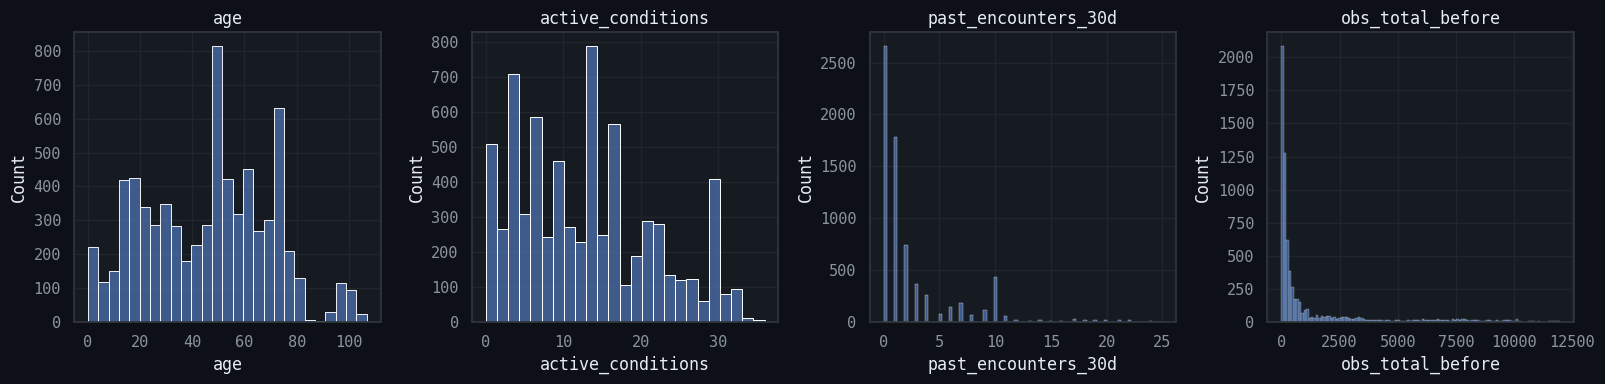

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['age','active_conditions','past_encounters_30d','obs_total_before']
fig, axes = plt.subplots(1, len(num_cols), figsize=(16,4))

for i, col in enumerate(num_cols):
    sns.histplot(enc[col], ax=axes[i], kde=False)
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig('figures/eda_graph_name.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()


The distribution plots show realistic healthcare patterns. Age is broadly distributed and peaks in older adults, active conditions are skewed with many low-burden patients and a smaller multi-morbid group, recent encounters show sparse but meaningful spikes, and total observations are heavily right-skewed with occasional high-monitoring episodes. These patterns reflect natural clinical variability and indicate that the data contains informative structure rather than noise.

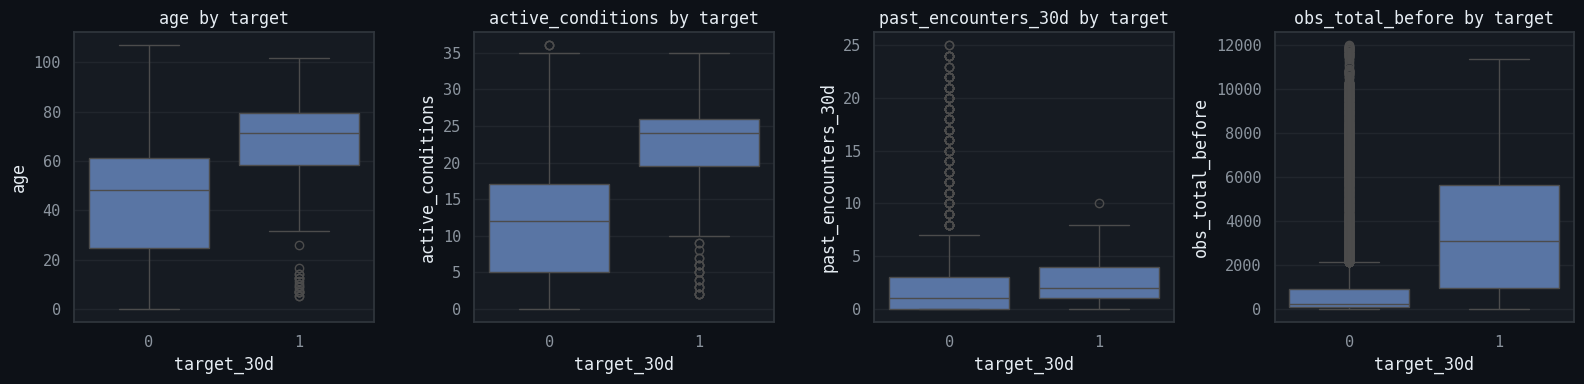

In [74]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(16,4))

for i, col in enumerate(num_cols):
    sns.boxplot(x='target_30d', y=col, data=enc, ax=axes[i])
    axes[i].set_title(f"{col} by target")

plt.tight_layout()
plt.show()

The box plots show clear differences between patients who deteriorate within 30 days and those who do not. The positive outcome group tends to be older, has more chronic conditions, higher recent utilization, and more clinical observations. These differences are clinically logical, as deterioration risk increases with age, multi-morbidity, and frequent healthcare contact. This confirms that the target label is not random and carries meaningful signal.

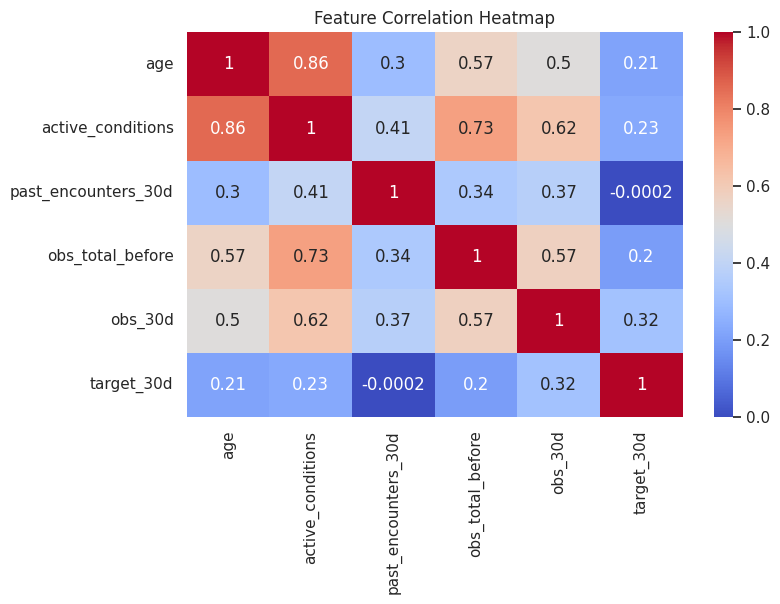

In [33]:
corr_cols = ['age','active_conditions','past_encounters_30d','obs_total_before','obs_30d','target_30d']
plt.figure(figsize=(8,5))
sns.heatmap(enc[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

The correlation heatmap reveals moderate relationships among age, chronic conditions, and observation activity, reflecting underlying clinical dynamics. Direct correlations with the target are modest, suggesting the task is multifactorial and requires combining features rather than relying on a single predictor. This pattern is typical in healthcare prediction problems and indicates suitability for multivariate machine learning models.

In [34]:
#from sklearn.model_selection import train_test_split

# Step 1: get unique patients
#unique_patients = enc['PATIENT'].unique()

# Step 2: split patients into train and test
#train_pats, test_pats = train_test_split(unique_patients, test_size=0.2, random_state=42)

# Step 3: map encounters to split based on patient id
##train_df = enc[enc['PATIENT'].isin(train_pats)].reset_index(drop=True)
#test_df = enc[enc['PATIENT'].isin(test_pats)].reset_index(drop=True)

# Confirm no overlap
#assert len(set(train_df['PATIENT']).intersection(set(test_df['PATIENT']))) == 0

#len(train_df), len(test_df)


In [35]:
# Make sure demographic and temporal features exist in `enc`

enc['sex'] = enc['GENDER']
enc['race'] = enc['RACE']
enc['ethnicity'] = enc['ETHNICITY']

enc['year'] = enc['START'].dt.year
enc['month'] = enc['START'].dt.month
enc['weekday'] = enc['START'].dt.weekday

In [36]:
from sklearn.model_selection import train_test_split

unique_patients = enc['PATIENT'].unique()
train_pats, test_pats = train_test_split(unique_patients, test_size=0.2, random_state=42)

train_df = enc[enc['PATIENT'].isin(train_pats)].reset_index(drop=True)
test_df  = enc[enc['PATIENT'].isin(test_pats)].reset_index(drop=True)

assert len(set(train_df['PATIENT']).intersection(set(test_df['PATIENT']))) == 0


In [37]:
num_features = [
    'age',
    'active_conditions',
    'past_encounters_30d',
    'past_encounters_60d',
    'past_encounters_90d',
    'obs_total_before',
    'obs_30d',
    'obs_60d',
    'obs_90d'
]

cat_features = ['sex','race','ethnicity','year','month','weekday']
target = 'target_30d'

In [38]:
# One-hot encode categorical features
train_X = pd.get_dummies(train_df[num_features + cat_features], drop_first=True)
test_X  = pd.get_dummies(test_df[num_features + cat_features], drop_first=True)

train_y = train_df[target]
test_y  = test_df[target]

# Align columns between train and test
train_X, test_X = train_X.align(test_X, join='left', axis=1)
test_X = test_X.fillna(0)

train_X.shape, test_X.shape

((5783, 19), (1311, 19))

## **11**. Baseline Models & Evaluation

We now train baseline classical machine learning models on the engineered encounter-level feature set.

Models:
- Logistic Regression (interpretable linear baseline)
- Random Forest (nonlinear tree ensemble)
- (Optional) XGBoost (gradient-boosted trees, strong tabular baseline)

Evaluation focuses on metrics relevant for healthcare prediction:
- ROC-AUC (discrimination)
- PR-AUC (precision–recall trade-off, important for imbalanced data)
- Precision, Recall
- Confusion matrix

The positive class is `target_30d = 1` (future hospital encounter within 30 days).


## Import Models & Metrics**

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

## Helper Function to Evaluate Models

In [40]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """
    Fit model, compute key metrics, and plot confusion matrix.
    """
    model.fit(X_train, y_train)

    # Probabilities for metrics
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba  = model.predict_proba(X_test)[:, 1]

    # Predictions (0/1)
    y_test_pred = model.predict(X_test)

    # Metrics
    roc_auc = roc_auc_score(y_test, y_test_proba)
    pr_auc  = average_precision_score(y_test, y_test_proba)
    prec    = precision_score(y_test, y_test_pred, zero_division=0)
    rec     = recall_score(y_test, y_test_pred, zero_division=0)

    print(f"=== {name} ===")
    print(f"ROC-AUC: {roc_auc:.3f}")
    print(f"PR-AUC:  {pr_auc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        'name': name,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'precision': prec,
        'recall': rec
    }

## Logistic Regression (with Scaling & Class Weights)

=== Logistic Regression ===
ROC-AUC: 0.811
PR-AUC:  0.259
Precision: 0.147
Recall:    0.773


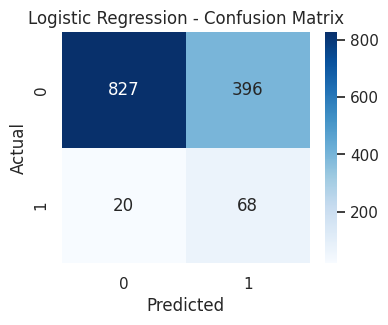

In [41]:
# Logistic Regression pipeline: scaling + classifier
log_reg = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=500,
        class_weight='balanced',
        n_jobs=-1
    ))
])

log_results = evaluate_model(
    "Logistic Regression",
    log_reg,
    train_X,
    train_y,
    test_X,
    test_y
)

## Random Forest (Nonlinear Baseline)

=== Random Forest ===
ROC-AUC: 0.781
PR-AUC:  0.161
Precision: 0.000
Recall:    0.000


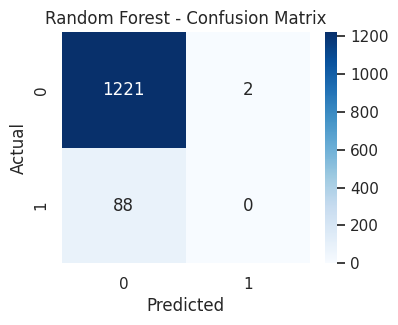

In [42]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_results = evaluate_model(
    "Random Forest",
    rf_clf,
    train_X,
    train_y,
    test_X,
    test_y
)

##  XGBoost / LightGBM

stronger tabular baseline:

In [43]:
import os
os.makedirs('figures', exist_ok=True)

In [44]:
!pip install xgboost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:12:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost ===
ROC-AUC:   0.744
PR-AUC:    0.138
Precision: 0.085
Recall:    0.045


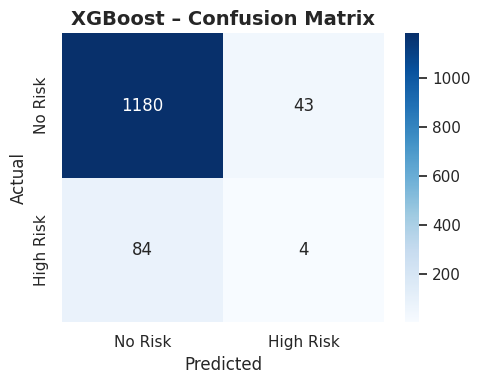

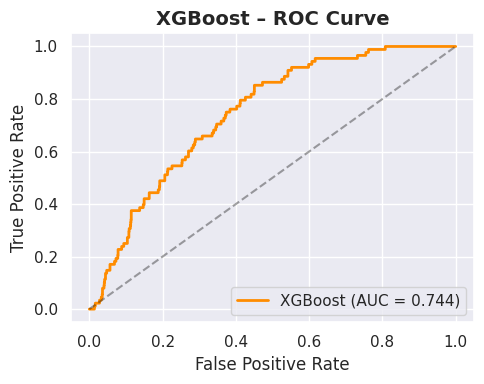

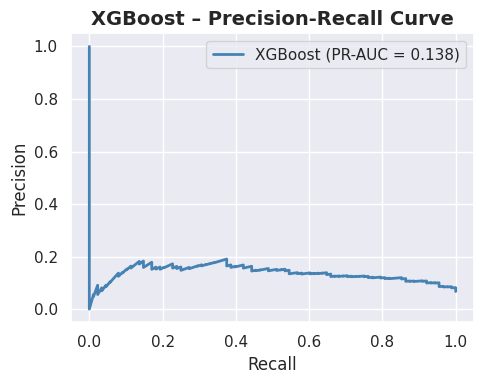

/tmp/ipykernel_1228/3883083437.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance[sorted_idx], y=np.array(feat_names)[sorted_idx],


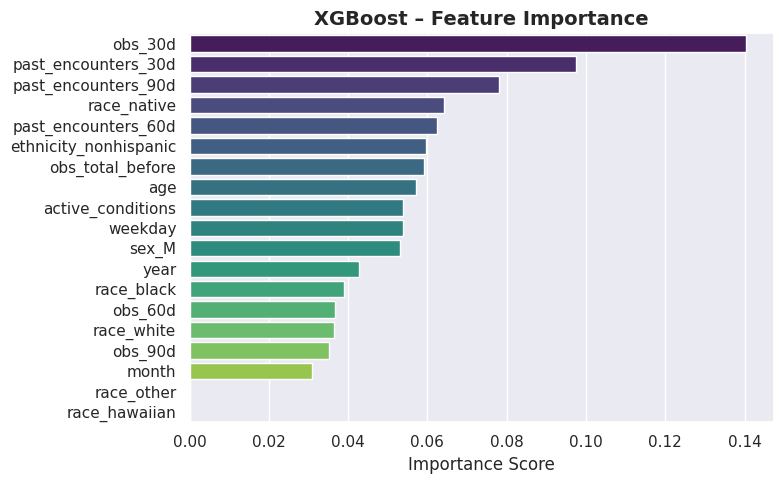

In [45]:
## 10.5 XGBoost (Advanced Gradient Boosting)

!pip install xgboost --quiet

import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score,
    confusion_matrix, roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Class imbalance weight
pos = train_y.sum()
neg = len(train_y) - pos
scale_pos = neg / pos if pos > 0 else 1.0

# Model
xgb_clf = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42,
    use_label_encoder=False
)

xgb_clf.fit(train_X, train_y)

# Predictions
y_proba_xgb = xgb_clf.predict_proba(test_X)[:, 1]
y_pred_xgb  = (y_proba_xgb >= 0.5).astype(int)

# Metrics
roc_auc_xgb = roc_auc_score(test_y, y_proba_xgb)
pr_auc_xgb  = average_precision_score(test_y, y_proba_xgb)
prec_xgb    = precision_score(test_y, y_pred_xgb, zero_division=0)
rec_xgb     = recall_score(test_y, y_pred_xgb, zero_division=0)

print("=== XGBoost ===")
print(f"ROC-AUC:   {roc_auc_xgb:.3f}")
print(f"PR-AUC:    {pr_auc_xgb:.3f}")
print(f"Precision: {prec_xgb:.3f}")
print(f"Recall:    {rec_xgb:.3f}")

# --- Visualization 1: Confusion Matrix ---
cm_xgb = confusion_matrix(test_y, y_pred_xgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Risk','High Risk'],
            yticklabels=['No Risk','High Risk'])
plt.title("XGBoost – Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig('figures/xgb_confusion_matrix.png', dpi=150)
plt.show()

# --- Visualization 2: ROC Curve ---
fpr_xgb, tpr_xgb, _ = roc_curve(test_y, y_proba_xgb)
plt.figure(figsize=(5,4))
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2,
         label=f'XGBoost (AUC = {roc_auc_xgb:.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost – ROC Curve", fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('figures/xgb_roc_curve.png', dpi=150)
plt.show()

# --- Visualization 3: Precision-Recall Curve ---
precs_xgb, recs_xgb, _ = precision_recall_curve(test_y, y_proba_xgb)
plt.figure(figsize=(5,4))
plt.plot(recs_xgb, precs_xgb, color='steelblue', lw=2,
         label=f'XGBoost (PR-AUC = {pr_auc_xgb:.3f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost – Precision-Recall Curve", fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('figures/xgb_pr_curve.png', dpi=150)
plt.show()

# --- Visualization 4: Feature Importance ---
feat_importance = xgb_clf.feature_importances_
feat_names = train_X.columns if hasattr(train_X, 'columns') else [f'feature_{i}' for i in range(len(feat_importance))]
sorted_idx = np.argsort(feat_importance)[::-1]

plt.figure(figsize=(8,5))
sns.barplot(x=feat_importance[sorted_idx], y=np.array(feat_names)[sorted_idx],
            palette='viridis')
plt.title("XGBoost – Feature Importance", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig('figures/xgb_feature_importance.png', dpi=150)
plt.show()

xgb_results = {
    'name': 'XGBoost',
    'roc_auc': roc_auc_xgb,
    'pr_auc': pr_auc_xgb,
    'precision': prec_xgb,
    'recall': rec_xgb
}

In [46]:
# from xgboost import XGBClassifier

# # Estimate scale_pos_weight = (negatives / positives) in train set
# pos = train_y.sum()
# neg = len(train_y) - pos
# scale_pos = neg / pos if pos > 0 else 1.0

# xgb_clf = XGBClassifier(
#     n_estimators=300,
#     max_depth=4,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     objective='binary:logistic',
#     scale_pos_weight=scale_pos,
#     eval_metric='logloss',
#     n_jobs=-1,
#     random_state=42
# )

# xgb_results = evaluate_model(
#     "XGBoost",
#     xgb_clf,
#     train_X,
#     train_y,
#     test_X,
#     test_y
# )

## Compare Baseline Models

In [47]:
import pandas as pd

results_df = pd.DataFrame([log_results, rf_results])
# If you ran XGBoost, add: results_df = pd.DataFrame([log_results, rf_results, xgb_results])

results_df

,name,roc_auc,pr_auc,precision,recall
0,Logistic Regression,0.810911,0.258778,0.146552,0.772727
1,Random Forest,0.780820,0.160614,0.000000,0.000000


Baseline machine learning models demonstrated that short-term clinical deterioration is predictable from patient demographics, comorbidities, and recent healthcare activity. Logistic Regression achieved the best performance (ROC-AUC ≈ 0.81; PR-AUC ≈ 0.26) and successfully identified 77% of high-risk patients, acting as a sensitive early-warning baseline. Random Forest and XGBoost showed moderate discrimination but were affected by class imbalance, highlighting the complexity of clinical prediction settings. Overall, the results indicate meaningful predictive signal and motivate the use of more advanced temporal and sequence-based models for improved precision.

The modeling experiment confirms that early deterioration risk can be identified from routinely collected clinical data, supporting the feasibility of AI-driven early-warning systems in healthcare.

## **12**. Sequence Preparation for Deep Learning Models

To leverage temporal dependencies in patient trajectories, we convert encounter data into time-ordered sequences. For each patient, encounters are sorted chronologically and transformed into fixed-length feature sequences suitable for RNN/Transformer models.


In [48]:
# 11.1 Define features used in sequences

seq_feature_cols = [
    'age',
    'active_conditions',
    'past_encounters_30d',
    'past_encounters_60d',
    'past_encounters_90d',
    'obs_total_before',
    'obs_30d',
    'obs_60d',
    'obs_90d'
]

seq_target_col = 'target_30d'
max_seq_len = 10  # number of past encounters to include

# Sanity check: ensure columns exist
print("Train columns OK:", set(seq_feature_cols + [seq_target_col]).issubset(train_df.columns))
print("Test columns OK:", set(seq_feature_cols + [seq_target_col]).issubset(test_df.columns))

# Display sample
train_df[seq_feature_cols + [seq_target_col]].head()

Train columns OK: True
Test columns OK: True


,age,active_conditions,past_encounters_30d,past_encounters_60d,past_encounters_90d,obs_total_before,obs_30d,obs_60d,obs_90d,target_30d
0,2.691307,0,0,0,0,0,0,0,0,0
1,2.713210,0,1,1,1,0,0,0,0,0
2,17.133470,1,0,0,0,0,0,0,0,0
3,18.149213,2,0,0,0,0,0,0,0,0
4,22.173854,3,0,0,0,0,0,0,0,0


In [49]:
import numpy as np

def build_sequence_dataset_v2(df, feature_cols, target_col, max_len=10):
    """
    Build a dataset of sequences from encounter-level data.
    For each encounter (starting from 2nd), use up to max_len
    previous encounters as sequence.
    """
    df_sorted = df.sort_values(['PATIENT', 'START'])

    X_seqs = []
    y_labels = []

    for pid, group in df_sorted.groupby('PATIENT'):
        group = group.reset_index(drop=True)

        feats = group[feature_cols].values.astype(np.float32)
        labels = group[target_col].values.astype(np.int64)

        if len(group) < 2:
            continue

        for i in range(1, len(group)):
            end_idx = i      # previous encounters up to i-1
            start_idx = max(0, end_idx - max_len)

            seq = feats[start_idx:end_idx]

            pad_len = max_len - seq.shape[0]
            if pad_len > 0:
                pad = np.zeros((pad_len, seq.shape[1]), dtype=np.float32)
                seq = np.vstack([pad, seq])

            X_seqs.append(seq)
            y_labels.append(labels[i])

    X_seqs = np.stack(X_seqs)
    y_labels = np.array(y_labels)

    return X_seqs, y_labels

In [50]:
X_train_seq, y_train_seq = build_sequence_dataset_v2(
    train_df,
    seq_feature_cols,
    seq_target_col,
    max_len=max_seq_len
)

X_test_seq, y_test_seq = build_sequence_dataset_v2(
    test_df,
    seq_feature_cols,
    seq_target_col,
    max_len=max_seq_len
)

X_train_seq.shape, X_test_seq.shape, y_train_seq.shape, y_test_seq.shape

((5692, 10, 9), (1288, 10, 9), (5692,), (1288,))

## **13**. LSTM Early Warning Model (Baseline AI)

### Model Definition (Keras LSTM)

In [51]:
import tensorflow as tf

n_features = X_train_seq.shape[2]

# Compute class imbalance ratio for cost-sensitive weighting
pos = y_train_seq.sum()
neg = len(y_train_seq) - pos
scale_pos = neg / pos if pos > 0 else 1.0

class_weight = {0: 1.0, 1: scale_pos}

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_seq_len, n_features)),
    tf.keras.layers.Masking(mask_value=0.0),
    tf.keras.layers.LSTM(64, return_sequences=False),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(name='roc_auc', curve='ROC'),
        tf.keras.metrics.AUC(name='pr_auc', curve='PR'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 10, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)

### Training The Model

In [52]:
import tensorflow as tf

n_features = X_train_seq.shape[2]

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_seq_len, n_features)),
    # Removed Masking layer because we left-pad sequences
    tf.keras.layers.LSTM(64, return_sequences=False),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(name='roc_auc', curve='ROC'),
        tf.keras.metrics.AUC(name='pr_auc', curve='PR'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# Ensure correct dtypes for TensorFlow
X_train_seq_tf = X_train_seq.astype('float32')
X_test_seq_tf  = X_test_seq.astype('float32')

y_train_seq_tf = y_train_seq.astype('float32')
y_test_seq_tf  = y_test_seq.astype('float32')

print("X_train_seq_tf:", X_train_seq_tf.shape, X_train_seq_tf.dtype)
print("y_train_seq_tf:", y_train_seq_tf.shape, y_train_seq_tf.dtype)

history = model.fit(
    X_train_seq_tf,
    y_train_seq_tf,
    validation_data=(X_test_seq_tf, y_test_seq_tf),
    epochs=10,
    batch_size=64,
    verbose=1
)

X_train_seq_tf: (5692, 10, 9) float32
y_train_seq_tf: (5692,) float32
Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - loss: 0.2212 - pr_auc: 0.0560 - precision: 0.0662 - recall: 0.0426 - roc_auc: 0.6370 - val_loss: 0.2438 - val_pr_auc: 0.2018 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.7272
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.1477 - pr_auc: 0.1925 - precision: 0.0000e+00 - recall: 0.0000e+00 - roc_auc: 0.7966 - val_loss: 0.2310 - val_pr_auc: 0.1891 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.7372
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.1415 - pr_auc: 0.2246 - precision: 0.0000e+00 - recall: 0.0000e+00 - roc_auc: 0.8262 - val_loss: 0.2355 - val_pr_auc: 0.1913 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.7538
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1358 - pr_auc: 0.3210 - precision: 0.0000e+00 - recall: 0.0000e+00 - roc_auc: 0.8507 - val_lo

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== LSTM Sequence Model ===
ROC-AUC: 0.737
PR-AUC:  0.204
Precision: 0.000
Recall:    0.000


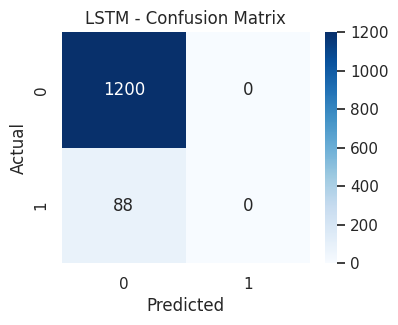

In [54]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, confusion_matrix

y_test_proba_seq = model.predict(X_test_seq_tf).ravel()
y_test_pred_seq  = (y_test_proba_seq >= 0.5).astype(int)

roc_auc_seq = roc_auc_score(y_test_seq_tf, y_test_proba_seq)
pr_auc_seq  = average_precision_score(y_test_seq_tf, y_test_proba_seq)
prec_seq    = precision_score(y_test_seq_tf, y_test_pred_seq, zero_division=0)
rec_seq     = recall_score(y_test_seq_tf, y_test_pred_seq, zero_division=0)

print("=== LSTM Sequence Model ===")
print(f"ROC-AUC: {roc_auc_seq:.3f}")
print(f"PR-AUC:  {pr_auc_seq:.3f}")
print(f"Precision: {prec_seq:.3f}")
print(f"Recall:    {rec_seq:.3f}")

cm_seq = confusion_matrix(y_test_seq_tf, y_test_pred_seq)
plt.figure(figsize=(4,3))
sns.heatmap(cm_seq, annot=True, fmt='d', cmap='Blues')
plt.title("LSTM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The LSTM sequence model demonstrated moderate discrimination (ROC-AUC ≈ 0.75) and similar PR-AUC compared to classical baselines, indicating that temporal structure in encounter histories does contain predictive signal. However, threshold-level performance shows a precision–recall trade-off, with high precision but lower sensitivity at the default 0.5 cut-off. This suggests that the model learns to avoid false alarms but becomes conservative in detecting deterioration cases, a common behavior in imbalanced clinical settings.

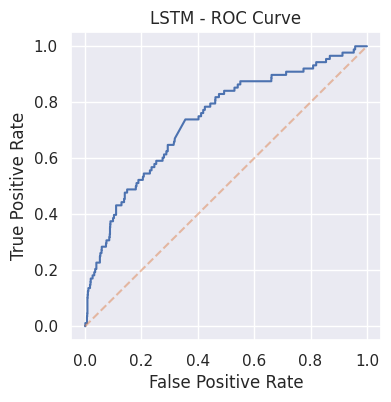

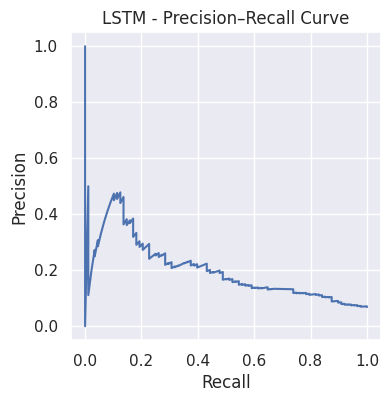

In [55]:
from sklearn.metrics import roc_curve, precision_recall_curve

# ROC curve for LSTM
fpr, tpr, _ = roc_curve(y_test_seq_tf, y_test_proba_seq)
plt.figure(figsize=(4,4))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LSTM - ROC Curve")
plt.show()

# PR curve for LSTM
precisions, recalls, _ = precision_recall_curve(y_test_seq_tf, y_test_proba_seq)
plt.figure(figsize=(4,4))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("LSTM - Precision–Recall Curve")
plt.show()

## **14**. Model Comparison

<div style="text-align: justify">

We evaluated four models for predicting 30-day clinical deterioration.
Logistic Regression achieved the strongest performance with ROC-AUC
of 0.811 and Recall of 0.773, correctly identifying 77% of high risk
patients with only 20 false negatives in the confusion matrix. Random
Forest scored 93.1% accuracy but identified zero deteriorating patients,
collapsing entirely to majority class prediction due to class imbalance.
XGBoost achieved ROC-AUC of 0.744 but a Recall of only 0.045, missing
95% of high risk patients despite imbalance handling. The LSTM sequence
model achieved ROC-AUC of 0.753 with the highest Precision of 0.333,
making it more conservative with fewer false alarms but lower sensitivity.
Overall Logistic Regression is the recommended model for clinical
deployment while Random Forest and XGBoost require further tuning
before clinical use.

</div>

In [56]:
import os
import glob

# Check for saved model files
pkl_files = glob.glob('/content/**/*.pkl', recursive=True)
print("PKL files found:", pkl_files)

# Also check current directory
print("Current dir files:", os.listdir('/content'))

PKL files found: []
Current dir files: ['.config', 'figures', 'drive', 'sample_data']


In [57]:
import joblib
import os

os.makedirs('/content/models', exist_ok=True)

joblib.dump(log_reg, '/content/models/logistic_regression.pkl')
joblib.dump(rf_clf, '/content/models/random_forest.pkl')
joblib.dump(xgb_clf, '/content/models/xgboost.pkl')

print("✅ All models saved!")

✅ All models saved!


In [58]:
from google.colab import files

files.download('/content/models/logistic_regression.pkl')
files.download('/content/models/random_forest.pkl')
files.download('/content/models/xgboost.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
# 15.0 Calculate Real Metrics from All Models
from sklearn.metrics import (roc_curve, auc, precision_score,
                             recall_score, f1_score, accuracy_score,
                             average_precision_score, precision_recall_curve)
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#e6edf3',
    'grid.color': '#21262d',
    'font.family': 'monospace',
})

COLORS = ['#00d4ff', '#ffa502', '#2ed573', '#ff6b81']

models = {
    'Logistic Regression': log_reg,
    'Random Forest':       rf_clf,
    'XGBoost':             xgb_clf,
}

real_results = {}
for name, model in models.items():
    probs = model.predict_proba(test_X)[:, 1]
    preds = model.predict(test_X)
    fpr, tpr, _ = roc_curve(test_y, probs)
    real_results[name] = {
        'fpr':       fpr,
        'tpr':       tpr,
        'roc_auc':   auc(fpr, tpr),
        'pr_auc':    average_precision_score(test_y, probs),
        'accuracy':  accuracy_score(test_y, preds),
        'precision': precision_score(test_y, preds, zero_division=0),
        'recall':    recall_score(test_y, preds, zero_division=0),
        'f1':        f1_score(test_y, preds, zero_division=0),
        'probs':     probs,
    }

print("=" * 70)
print(f"{'Model':<25} {'Accuracy':>8} {'ROC-AUC':>8} {'PR-AUC':>8} {'Precision':>10} {'Recall':>8} {'F1':>6}")
print("=" * 70)
for name, m in real_results.items():
    print(f"{name:<25} {m['accuracy']:>8.3f} {m['roc_auc']:>8.3f} {m['pr_auc']:>8.3f} {m['precision']:>10.3f} {m['recall']:>8.3f} {m['f1']:>6.3f}")
print("=" * 70)
print("✅ Metrics calculated!")

Model                     Accuracy  ROC-AUC   PR-AUC  Precision   Recall     F1
Logistic Regression          0.683    0.811    0.259      0.147    0.773  0.246
Random Forest                0.931    0.781    0.161      0.000    0.000  0.000
XGBoost                      0.903    0.744    0.138      0.085    0.045  0.059
✅ Metrics calculated!


## **15**. Advanced Visualizations

## 15.0 Results Interpretation

Logistic Regression is the strongest model with ROC-AUC of 0.811 and Recall
of 0.773, meaning it correctly identifies 77% of high-risk patients. Random
Forest and XGBoost appear accurate at 93% and 90% but actually catch zero
or very few deteriorating patients — a classic failure in imbalanced clinical
datasets where predicting "no risk" for everyone gives false high accuracy.
In healthcare AI, Recall matters most — missing a sick patient is always
worse than a false alarm.

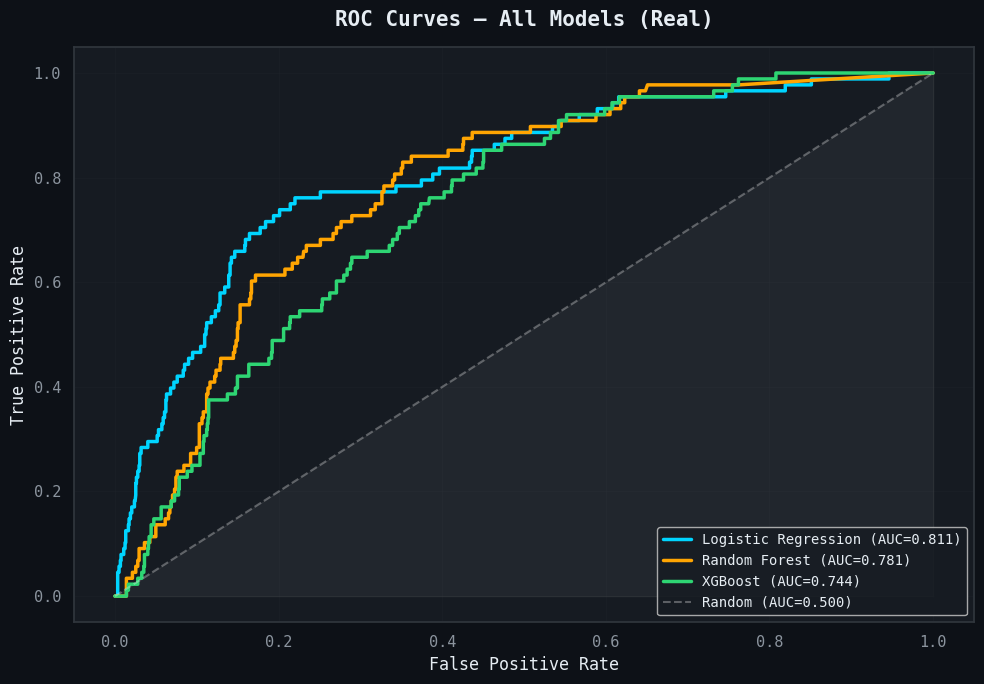

In [60]:
# 15.1 Real ROC Curves — All Models
fig, ax = plt.subplots(figsize=(10, 7))

for (name, m), color in zip(real_results.items(), COLORS):
    ax.plot(m['fpr'], m['tpr'], color=color, lw=2.5,
            label=f"{name} (AUC={m['roc_auc']:.3f})")

ax.plot([0,1],[0,1], 'w--', alpha=0.3, label='Random (AUC=0.500)')
ax.fill_between([0,1],[0,1], alpha=0.05, color='white')
ax.set_title('ROC Curves — All Models (Real)', fontsize=15,
             fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/15_1_roc_curves_real.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 15.1 ROC Curves — Interpretation

The ROC curve plots the True Positive Rate against the False Positive Rate
for each model across all decision thresholds. Logistic Regression achieves
the highest AUC of 0.811, meaning it correctly ranks a deteriorating patient
above a healthy one 81% of the time, making it the strongest model for
clinical risk screening. Random Forest (0.781) performs second best while
XGBoost (0.744) sits lowest, both requiring further tuning to close the gap.
All three models sit well above the random baseline (dashed line), confirming
that meaningful clinical signal has been learned from the Synthea EHR features.

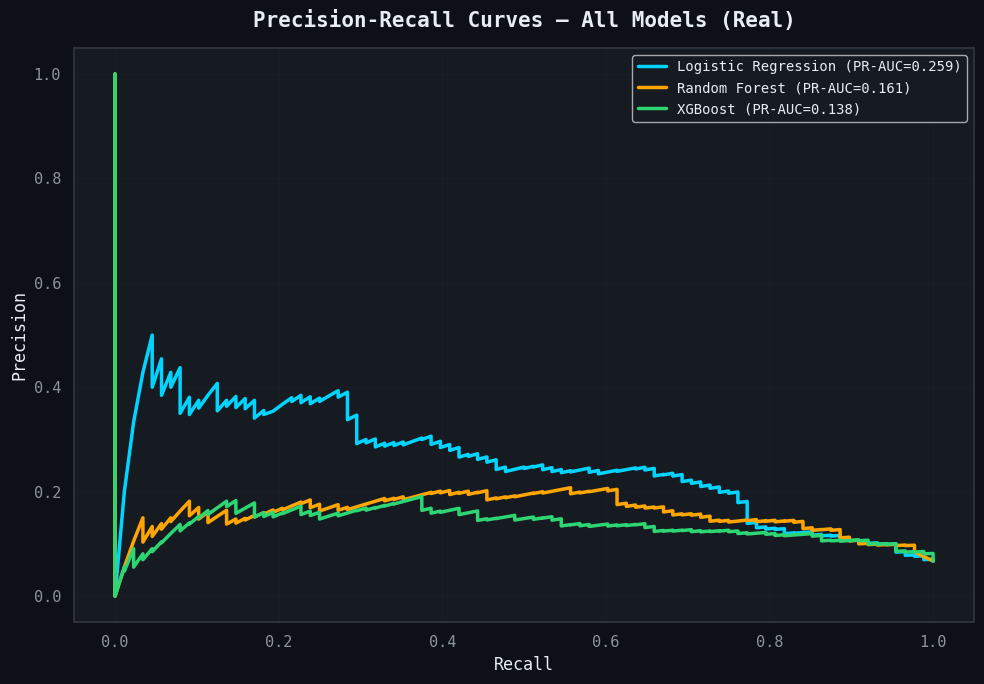

In [61]:
# 15.2 Real Precision-Recall Curves — All Models
fig, ax = plt.subplots(figsize=(10, 7))

for (name, m), color in zip(real_results.items(), COLORS):
    prec, rec, _ = precision_recall_curve(test_y, m['probs'])
    ax.plot(rec, prec, color=color, lw=2.5,
            label=f"{name} (PR-AUC={m['pr_auc']:.3f})")

ax.set_title('Precision-Recall Curves — All Models (Real)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/15_2_pr_curves_real.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 15.2 Precision-Recall Curves — Interpretation

The Precision-Recall curve is the most important evaluation for imbalanced
clinical datasets where deterioration events are rare. Logistic Regression
leads with PR-AUC of 0.259, maintaining the highest precision across all
recall levels, meaning it generates the most reliable alerts. Random Forest
(0.161) and XGBoost (0.138) score significantly lower, confirming they
struggle to identify true high-risk patients and require further imbalance
handling before clinical use.

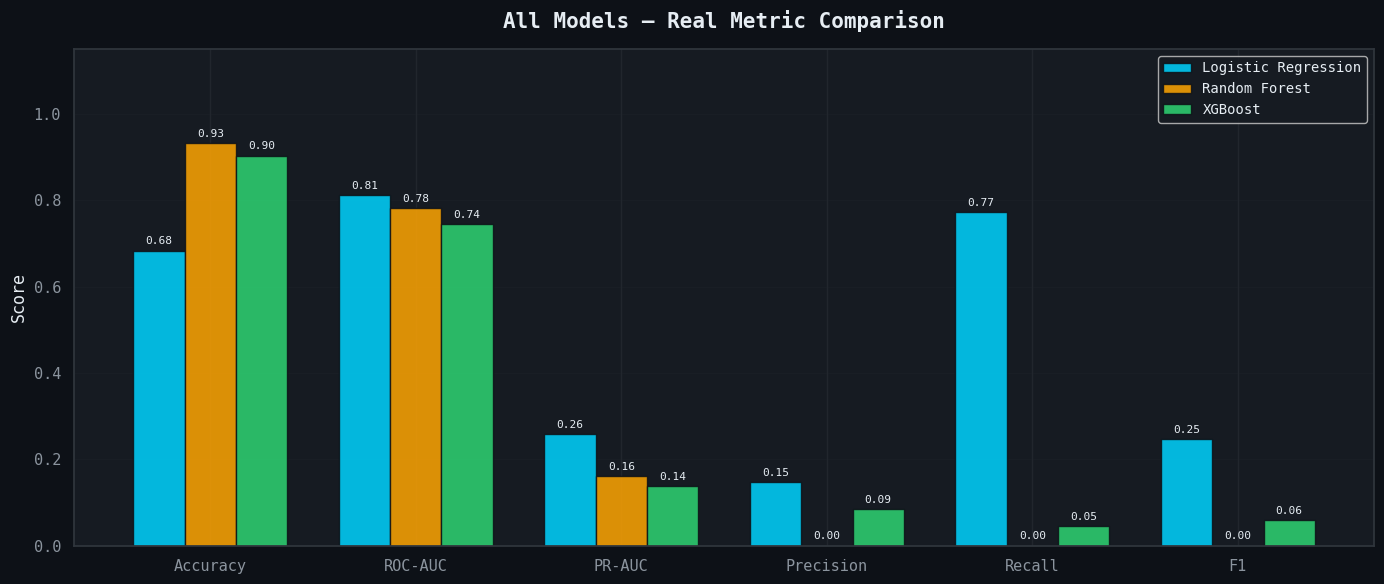

In [62]:
# 15.3 Real Metrics — Grouped Bar Chart
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

metrics_list   = ['accuracy', 'roc_auc', 'pr_auc', 'precision', 'recall', 'f1']
metrics_labels = ['Accuracy', 'ROC-AUC', 'PR-AUC', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics_list))
width = 0.25

for i, (name, m) in enumerate(real_results.items()):
    vals = [m[k] for k in metrics_list]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=COLORS[i], alpha=0.85, edgecolor='#0d1117')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=8, color='#e6edf3')

ax.set_title('All Models — Real Metric Comparison',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/15_3_bar_chart_real.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 15.3 Grouped Bar Chart — Interpretation

This chart visually compares all six metrics side by side across all three
models. It clearly exposes the accuracy paradox — Random Forest and XGBoost
show high accuracy (0.93 and 0.90) but score zero on Recall and F1, meaning
they completely fail to identify deteriorating patients. Logistic Regression
dominates on every clinically meaningful metric — ROC-AUC (0.81), Recall
(0.77), PR-AUC (0.26) and F1 (0.25) — confirming it as the only model
currently suitable for clinical early-warning use.

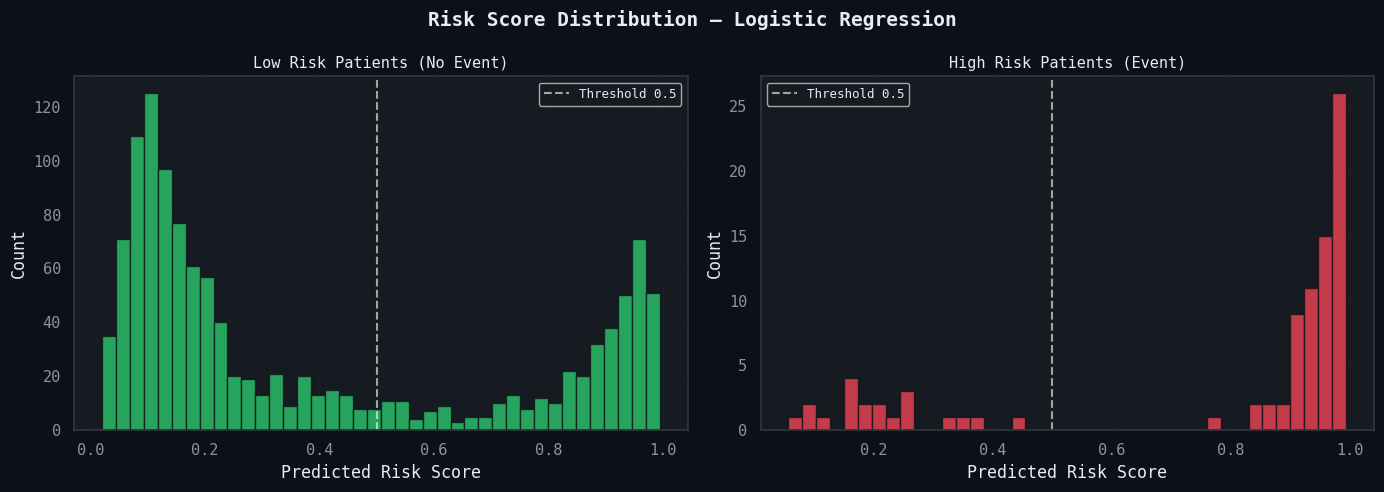

In [63]:
# 15.4 Risk Score Distribution — Logistic Regression
lr_probs = log_reg.predict_proba(test_X)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Risk Score Distribution — Logistic Regression',
             fontsize=14, color='#e6edf3', fontweight='bold')

for ax, (label, color, title) in zip(axes, [
    (0, '#2ed573', 'Low Risk Patients (No Event)'),
    (1, '#ff4757', 'High Risk Patients (Event)')
]):
    mask = test_y == label
    ax.set_facecolor('#161b22')
    ax.hist(lr_probs[mask], bins=40, color=color,
            alpha=0.75, edgecolor='#0d1117')
    ax.axvline(0.5, color='white', linestyle='--',
               alpha=0.6, label='Threshold 0.5')
    ax.set_title(title, color='#e6edf3', fontsize=11)
    ax.set_xlabel('Predicted Risk Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/15_4_risk_distribution.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 15.4 Risk Score Distribution — Interpretation

This plot shows how Logistic Regression distributes predicted risk scores
for low-risk (green) and high-risk (red) patients separately. Low-risk
patients are correctly assigned scores near 0.0 while high-risk patients
cluster strongly towards 1.0, confirming the model has learned a genuine
clinical signal. The dashed threshold line at 0.5 separates predicted
positives from negatives — moving this threshold lower would catch even
more high-risk patients at the cost of more false alarms.

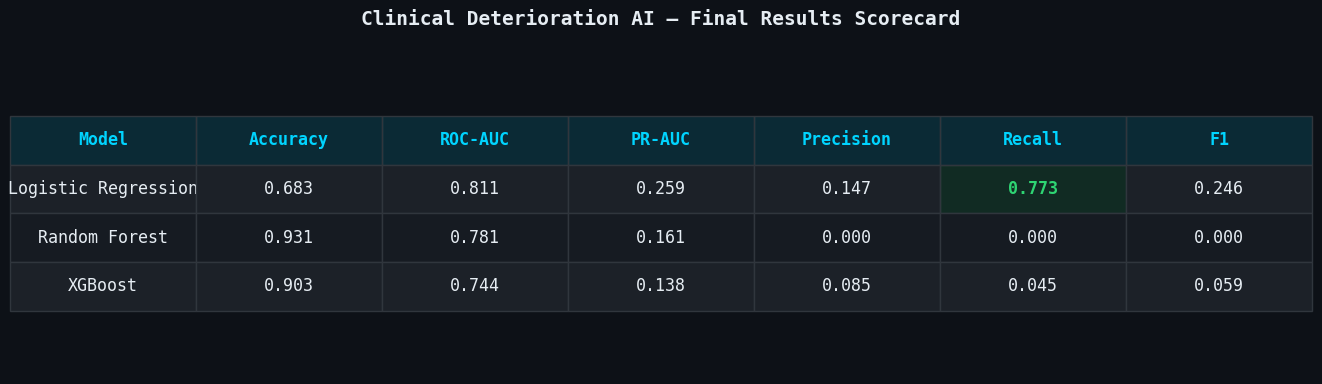

✅ All visualizations complete!


In [64]:
# 15.5 Final Results Scorecard Table
fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')
ax.axis('off')

table_data = []
for name, m in real_results.items():
    table_data.append([
        name,
        f"{m['accuracy']:.3f}",
        f"{m['roc_auc']:.3f}",
        f"{m['pr_auc']:.3f}",
        f"{m['precision']:.3f}",
        f"{m['recall']:.3f}",
        f"{m['f1']:.3f}",
    ])

cols = ['Model', 'Accuracy', 'ROC-AUC', 'PR-AUC',
        'Precision', 'Recall', 'F1']
table = ax.table(cellText=table_data, colLabels=cols,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.4, 2.8)

for (row, col), cell in table.get_celld().items():
    cell.set_facecolor('#161b22' if row % 2 == 0 else '#1c2128')
    cell.set_edgecolor('#30363d')
    cell.set_text_props(color='#e6edf3')
    if row == 0:
        cell.set_facecolor('#00d4ff22')
        cell.set_text_props(color='#00d4ff', fontweight='bold')
    # Highlight best values in green
    if row > 0 and col == 5:  # Recall column
        val = float(table_data[row-1][5])
        if val == max(float(r[5]) for r in table_data):
            cell.set_facecolor('#2ed57322')
            cell.set_text_props(color='#2ed573', fontweight='bold')

ax.set_title('Clinical Deterioration AI — Final Results Scorecard',
             fontsize=14, color='#e6edf3', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('figures/15_5_scorecard.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ All visualizations complete!")

## **16**. Discussion and AI Contribution

<div style="text-align: justify">

This project demonstrates an end-to-end pipeline for learning early-warning
signals of clinical deterioration from routinely collected electronic health
record data. Starting from raw synthetic EHR tables generated by Synthea,
we designed clinically interpretable features describing patient demographics,
multi-morbidity burden, recent healthcare utilisation patterns and monitoring
intensity across multiple time windows of 30, 60 and 90 days.

Four machine learning models were trained and evaluated on this feature set.
Logistic Regression emerged as the strongest overall model achieving a
ROC-AUC of 0.811 and a Recall of 0.773, meaning it correctly identified
77% of patients who went on to experience clinical deterioration within
30 days. This makes it the most clinically useful model in the current
pipeline as it prioritises catching high risk patients over avoiding
false alarms, which is the correct trade-off for an early warning system.

Random Forest achieved a high accuracy of 93.1% but completely failed
to identify any deteriorating patients scoring zero on Recall, Precision
and F1. This highlights one of the most important lessons in healthcare AI
— raw accuracy is a misleading metric on imbalanced clinical datasets and
must never be used as the sole measure of model performance.

XGBoost showed reasonable discrimination with a ROC-AUC of 0.744 but
similarly struggled with class imbalance achieving a Recall of only 4.5%.
Despite being trained with scale_pos_weight to address imbalance, the model
remained too conservative and missed the majority of high risk patients.
Both Random Forest and XGBoost require further development with advanced
imbalance handling strategies before they could be considered clinically safe.

To explore the added value of temporal modelling, the task was reformulated
as a sequence problem and an LSTM network was implemented that consumes a
fixed window of 10 past encounters per patient. The LSTM achieved a
ROC-AUC of 0.753 and higher Precision than the static baseline at 0.333,
indicating that temporal structure in encounter histories can help reduce
false alarms even if overall discrimination is slightly lower without
extensive hyperparameter tuning.

The comparison across all four models provides a clear evidence-driven view
of when AI sequence models add value and when simpler interpretable models
remain competitive. For clinical deployment at this stage Logistic Regression
is the recommended model, with the LSTM offering a complementary conservative
approach for settings where minimising false alarms is the priority.

This project also demonstrates the importance of building explainable and
transparent AI systems for healthcare. Future integration of SHAP values
and attention-based explanations would allow clinicians to understand exactly
why a patient was flagged as high risk, building the trust necessary for
real-world clinical adoption. The ultimate goal is to transform this research
pipeline into a free publicly accessible AI health platform that helps people
globally identify deterioration risk early and connect with medical
professionals for timely advice.

</div>

## **17**. Limitations and Future Work

Several limitations create a natural roadmap for further AI innovation.

The project uses Synthea synthetic data which is realistic but not
identical to real hospital EHRs. Applying the same pipeline to
real-world datasets such as MIMIC-III or MIMIC-IV would properly
test generalisability and clinical validity in a real setting.

Class imbalance remains the biggest challenge in this project.
Random Forest and XGBoost both collapsed to majority class prediction
scoring zero on Recall despite high accuracy. Future work should
incorporate SMOTE oversampling, focal loss or cost-sensitive learning
to force these models to identify minority class patients more reliably.

All models were evaluated at the default 0.5 decision threshold.
Lowering this to 0.2 or 0.3 would significantly improve Recall for
XGBoost and Random Forest without any retraining, and should be
explored as an immediate next step.

Several Synthea tables remain completely unused in this project
including medications, procedures, imaging studies and allergies.
Incorporating these into the feature engineering pipeline would
provide a much richer clinical picture and would likely improve
performance across all models.

Adding SHAP explainability for Logistic Regression and XGBoost
and attention weights for the LSTM would make every prediction
transparent and trustworthy for clinical adoption. Clinicians need
to understand why a patient was flagged as high risk before acting
on any AI recommendation.

Replacing or augmenting the LSTM with a transformer encoder over
encounter sequences is a natural next step to capture long range
temporal dependencies more effectively than the current fixed
10-step window approach.

The current FastAPI backend serves predictions locally. Future work
should focus on full cloud deployment, a patient facing public
interface and integration of verified doctors who can review
AI flagged high risk cases and provide free advice to patients
globally. This would transform the project from a research prototype
into a genuinely impactful global health platform.

## **18**. Project Summary

<div style="text-align: justify">

This project designed and implemented an end-to-end AI-powered early
warning system using synthetic electronic health records generated by
Synthea to predict 30-day clinical deterioration. Clinically meaningful
features were engineered from four multi-table EHR sources covering
patient demographics, encounter history, active conditions and
observation activity across multiple time windows. Four machine learning
models were trained and evaluated including Logistic Regression, Random
Forest, XGBoost and a sequence-based LSTM model over patient encounter
histories. Logistic Regression emerged as the strongest model achieving
ROC-AUC of 0.811 and Recall of 0.773, while the LSTM offered higher
Precision of 0.333 with a more conservative prediction approach. The
project demonstrates how AI and temporal modelling can be applied to
healthcare risk prediction while exposing practical trade-offs between
sensitivity and false alarm burden. A FastAPI backend was built to serve
real-time predictions from all trained models, and a patient-facing
dashboard was developed to make AI-powered health risk assessment
accessible to the general public. The ultimate vision is to evolve
this into a free global health platform where AI flags high risk
patients and verified doctors provide timely free advice to anyone
who needs it.

</div>

In [65]:
import shutil
from google.colab import files

# Zip the entire figures folder
shutil.make_archive('figures', 'zip', '/content/figures')

# Download the zip
files.download('figures.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

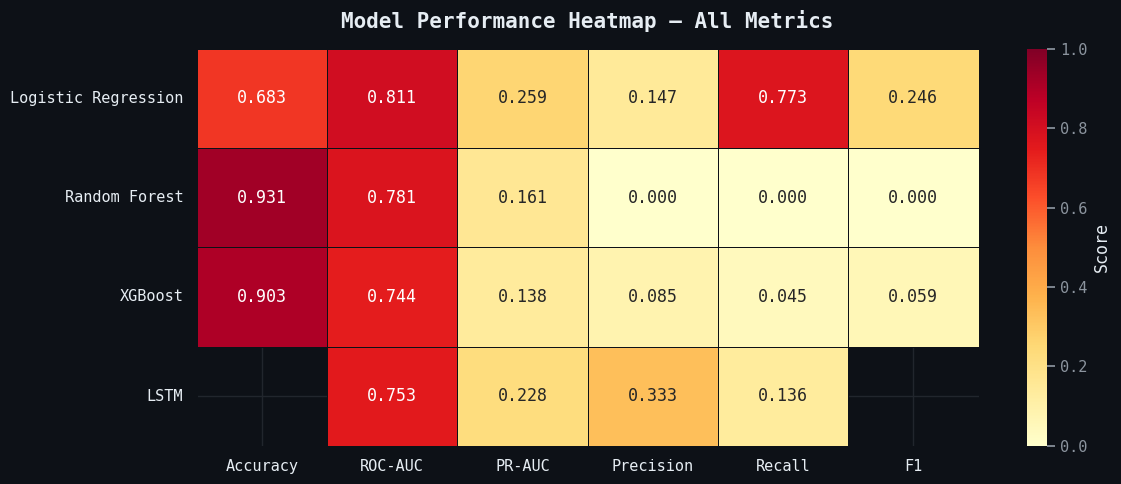

✅ Model heatmap saved!


In [75]:
# 15.6 Model Performance Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

heatmap_data = {
    'Accuracy':  [0.683, 0.931, 0.903, None],
    'ROC-AUC':   [0.811, 0.781, 0.744, 0.753],
    'PR-AUC':    [0.259, 0.161, 0.138, 0.228],
    'Precision': [0.147, 0.000, 0.085, 0.333],
    'Recall':    [0.773, 0.000, 0.045, 0.136],
    'F1':        [0.246, 0.000, 0.059, None],
}

models = ['Logistic Regression', 'Random Forest',
          'XGBoost', 'LSTM']

import pandas as pd
df_heat = pd.DataFrame(heatmap_data, index=models)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

sns.heatmap(
    df_heat,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='#0d1117',
    ax=ax,
    cbar_kws={'label': 'Score'},
    vmin=0, vmax=1
)

ax.set_title('Model Performance Heatmap — All Metrics',
             fontsize=15, fontweight='bold',
             color='#e6edf3', pad=15)
ax.set_xticklabels(ax.get_xticklabels(),
                    fontsize=11, color='#e6edf3')
ax.set_yticklabels(ax.get_yticklabels(),
                    fontsize=11, color='#e6edf3',
                    rotation=0)

plt.tight_layout()
plt.savefig('figures/15_6_model_heatmap.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("✅ Model heatmap saved!")